6133-010402D Асташин С.В.

In [28]:
# проверяем GPU и компилятор

!nvidia-smi
!nvcc --version

Tue Apr 14 20:00:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Saving manwithnoname-main1.jpg to manwithnoname-main1 (2).jpg
Исходный файл: manwithnoname-main1 (2).jpg
Формат: JPEG
Размер: (1600, 2400)
Режим: RGB
Сохранены файлы:
 - original_gray.bmp  -> чистое grayscale BMP
 - input.bmp          -> вход для CUDA


/tmp/ipykernel_7336/3550273619.py:53: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  input_img = Image.fromarray(arr, mode="L")


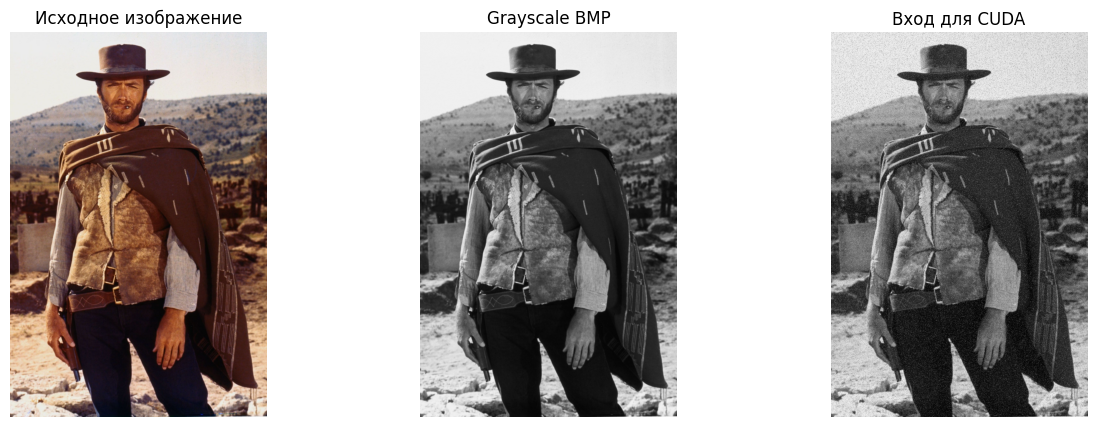

In [29]:
# загрузка входного изображения

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# НАСТРОЙКИ

ADD_NOISE = True       # добавить salt-and-pepper noise для демонстрации
NOISE_PROB = 0.08      # доля зашумленных пикселей, например 0.03 ... 0.10
RANDOM_SEED = 42       # для воспроизводимости

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("Файл не загружен")

src_name = next(iter(uploaded.keys()))

img = Image.open(src_name)

print(f"Исходный файл: {src_name}")
print(f"Формат: {img.format}")
print(f"Размер: {img.size}")
print(f"Режим: {img.mode}")

# Если есть альфа-канал — кладем на белый фон
if img.mode in ("RGBA", "LA") or (img.mode == "P" and "transparency" in img.info):
    rgba = img.convert("RGBA")
    bg = Image.new("RGBA", rgba.size, (255, 255, 255, 255))
    img = Image.alpha_composite(bg, rgba)

# Перевод в grayscale
gray = img.convert("L")

# Сохраняем чистую grayscale BMP-версию
gray.save("original_gray.bmp")

# Дальше формируем именно вход для CUDA
arr = np.array(gray, dtype=np.uint8)

if ADD_NOISE:
    rng = np.random.default_rng(RANDOM_SEED)
    rnd = rng.random(arr.shape)

    # "pepper" = черные пиксели
    arr[rnd < (NOISE_PROB / 2)] = 0

    # "salt" = белые пиксели
    arr[(rnd >= (NOISE_PROB / 2)) & (rnd < NOISE_PROB)] = 255

input_img = Image.fromarray(arr, mode="L")
input_img.save("input.bmp")

print("Сохранены файлы:")
print(" - original_gray.bmp  -> чистое grayscale BMP")
print(" - input.bmp          -> вход для CUDA")

# Визуализация
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(Image.open(src_name))
plt.title("Исходное изображение")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Image.open("original_gray.bmp"), cmap="gray")
plt.title("Grayscale BMP")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Image.open("input.bmp"), cmap="gray")
plt.title("Вход для CUDA")
plt.axis("off")

plt.show()

In [30]:
# CUDA-код программы

%%writefile median_filter_texture.cu
#include <cuda_runtime.h>

#include <chrono>
#include <cstdint>
#include <cstdlib>
#include <cstring>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <stdexcept>
#include <string>
#include <vector>

#define CUDA_CHECK(call)                                                          \
    do {                                                                          \
        cudaError_t err__ = (call);                                               \
        if (err__ != cudaSuccess) {                                               \
            std::cerr << "CUDA error: " << cudaGetErrorString(err__)              \
                      << " at " << __FILE__ << ":" << __LINE__ << std::endl;      \
            std::exit(EXIT_FAILURE);                                              \
        }                                                                         \
    } while (0)

#pragma pack(push, 1)
struct BMPFileHeader {
    uint16_t bfType;
    uint32_t bfSize;
    uint16_t bfReserved1;
    uint16_t bfReserved2;
    uint32_t bfOffBits;
};

struct BMPInfoHeader {
    uint32_t biSize;
    int32_t  biWidth;
    int32_t  biHeight;
    uint16_t biPlanes;
    uint16_t biBitCount;
    uint32_t biCompression;
    uint32_t biSizeImage;
    int32_t  biXPelsPerMeter;
    int32_t  biYPelsPerMeter;
    uint32_t biClrUsed;
    uint32_t biClrImportant;
};
#pragma pack(pop)

static inline unsigned char rgbToGray(unsigned char r, unsigned char g, unsigned char b) {
    return static_cast<unsigned char>((77u * r + 150u * g + 29u * b) >> 8);
}

std::vector<unsigned char> loadBMPGray(const std::string& filename, int& width, int& height) {
    std::ifstream file(filename, std::ios::binary);
    if (!file) {
        throw std::runtime_error("Cannot open input file: " + filename);
    }

    BMPFileHeader fileHeader{};
    BMPInfoHeader infoHeader{};

    file.read(reinterpret_cast<char*>(&fileHeader), sizeof(fileHeader));
    file.read(reinterpret_cast<char*>(&infoHeader), sizeof(infoHeader));

    if (!file) throw std::runtime_error("Failed to read BMP headers");
    if (fileHeader.bfType != 0x4D42) throw std::runtime_error("Input file is not a BMP");
    if (infoHeader.biSize < 40) throw std::runtime_error("Unsupported BMP header");
    if (infoHeader.biPlanes != 1) throw std::runtime_error("Unsupported BMP: biPlanes must be 1");
    if (infoHeader.biCompression != 0) throw std::runtime_error("Only uncompressed BMP is supported");
    if (infoHeader.biWidth <= 0 || infoHeader.biHeight == 0) throw std::runtime_error("Invalid BMP dimensions");

    if (infoHeader.biBitCount != 8 && infoHeader.biBitCount != 24 && infoHeader.biBitCount != 32) {
        throw std::runtime_error("Supported BMP formats: 8-bit, 24-bit, 32-bit");
    }

    if (infoHeader.biSize > sizeof(BMPInfoHeader)) {
        std::streamoff extra = static_cast<std::streamoff>(infoHeader.biSize) -
                               static_cast<std::streamoff>(sizeof(BMPInfoHeader));
        file.seekg(extra, std::ios::cur);
    }

    width = infoHeader.biWidth;
    height = (infoHeader.biHeight > 0) ? infoHeader.biHeight : -infoHeader.biHeight;
    const bool bottomUp = (infoHeader.biHeight > 0);

    std::vector<unsigned char> paletteGray;

    if (infoHeader.biBitCount == 8) {
        std::streamoff currentPos = static_cast<std::streamoff>(file.tellg());
        std::streamoff bytesBeforePixels = static_cast<std::streamoff>(fileHeader.bfOffBits) - currentPos;

        if (bytesBeforePixels > 0) {
            size_t paletteEntries = static_cast<size_t>(bytesBeforePixels / 4);
            paletteGray.resize(paletteEntries);

            for (size_t i = 0; i < paletteEntries; ++i) {
                unsigned char bgra[4];
                file.read(reinterpret_cast<char*>(bgra), 4);
                if (!file) throw std::runtime_error("Failed to read BMP palette");
                paletteGray[i] = rgbToGray(bgra[2], bgra[1], bgra[0]);
            }
        }
    }

    file.seekg(fileHeader.bfOffBits, std::ios::beg);

    const size_t rowStride =
        ((static_cast<size_t>(width) * infoHeader.biBitCount + 31u) / 32u) * 4u;

    std::vector<unsigned char> image(static_cast<size_t>(width) * height);
    std::vector<unsigned char> row(rowStride);

    for (int rowIdx = 0; rowIdx < height; ++rowIdx) {
        file.read(reinterpret_cast<char*>(row.data()), static_cast<std::streamsize>(rowStride));
        if (!file) throw std::runtime_error("Failed to read BMP pixel data");

        int y = bottomUp ? (height - 1 - rowIdx) : rowIdx;

        if (infoHeader.biBitCount == 8) {
            for (int x = 0; x < width; ++x) {
                unsigned char idx = row[static_cast<size_t>(x)];
                unsigned char gray = idx;
                if (!paletteGray.empty() && static_cast<size_t>(idx) < paletteGray.size()) {
                    gray = paletteGray[idx];
                }
                image[static_cast<size_t>(y) * width + x] = gray;
            }
        } else if (infoHeader.biBitCount == 24) {
            for (int x = 0; x < width; ++x) {
                const size_t base = static_cast<size_t>(x) * 3u;
                unsigned char b = row[base + 0];
                unsigned char g = row[base + 1];
                unsigned char r = row[base + 2];
                image[static_cast<size_t>(y) * width + x] = rgbToGray(r, g, b);
            }
        } else {
            for (int x = 0; x < width; ++x) {
                const size_t base = static_cast<size_t>(x) * 4u;
                unsigned char b = row[base + 0];
                unsigned char g = row[base + 1];
                unsigned char r = row[base + 2];
                image[static_cast<size_t>(y) * width + x] = rgbToGray(r, g, b);
            }
        }
    }

    return image;
}

void saveBMPGray(const std::string& filename,
                 const std::vector<unsigned char>& image,
                 int width,
                 int height) {
    std::ofstream file(filename, std::ios::binary);
    if (!file) throw std::runtime_error("Cannot open output file: " + filename);

    const size_t rowStride = ((static_cast<size_t>(width) + 3u) / 4u) * 4u;
    const uint32_t paletteSize = 256u * 4u;
    const uint32_t pixelDataSize = static_cast<uint32_t>(rowStride * height);

    BMPFileHeader fileHeader{};
    fileHeader.bfType = 0x4D42;
    fileHeader.bfOffBits = sizeof(BMPFileHeader) + sizeof(BMPInfoHeader) + paletteSize;
    fileHeader.bfSize = fileHeader.bfOffBits + pixelDataSize;

    BMPInfoHeader infoHeader{};
    infoHeader.biSize = sizeof(BMPInfoHeader);
    infoHeader.biWidth = width;
    infoHeader.biHeight = height;
    infoHeader.biPlanes = 1;
    infoHeader.biBitCount = 8;
    infoHeader.biCompression = 0;
    infoHeader.biSizeImage = pixelDataSize;
    infoHeader.biClrUsed = 256;
    infoHeader.biClrImportant = 256;

    file.write(reinterpret_cast<const char*>(&fileHeader), sizeof(fileHeader));
    file.write(reinterpret_cast<const char*>(&infoHeader), sizeof(infoHeader));

    for (int i = 0; i < 256; ++i) {
        unsigned char entry[4] = {
            static_cast<unsigned char>(i),
            static_cast<unsigned char>(i),
            static_cast<unsigned char>(i),
            0
        };
        file.write(reinterpret_cast<const char*>(entry), 4);
    }

    std::vector<unsigned char> row(rowStride, 0);

    for (int y = height - 1; y >= 0; --y) {
        std::memcpy(row.data(), &image[static_cast<size_t>(y) * width], static_cast<size_t>(width));
        file.write(reinterpret_cast<const char*>(row.data()), static_cast<std::streamsize>(rowStride));
    }

    if (!file) throw std::runtime_error("Failed to write output BMP");
}

__device__ __forceinline__ void bubbleSort9(unsigned char* v) {
    for (int i = 0; i < 8; ++i) {
        for (int j = 0; j < 8 - i; ++j) {
            if (v[j] > v[j + 1]) {
                unsigned char t = v[j];
                v[j] = v[j + 1];
                v[j + 1] = t;
            }
        }
    }
}

__global__ void median9TextureKernel(cudaTextureObject_t texObj,
                                     unsigned char* output,
                                     int width,
                                     int height) {
    const int x = blockIdx.x * blockDim.x + threadIdx.x;
    const int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= width || y >= height) return;

    unsigned char window[9];
    int k = 0;

    for (int dy = -1; dy <= 1; ++dy) {
        for (int dx = -1; dx <= 1; ++dx) {
            window[k++] = tex2D<unsigned char>(
                texObj,
                static_cast<float>(x + dx) + 0.5f,
                static_cast<float>(y + dy) + 0.5f
            );
        }
    }

    bubbleSort9(window);
    output[static_cast<size_t>(y) * width + x] = window[4];
}

int main(int argc, char** argv) {
    using clock_type = std::chrono::steady_clock;

    try {
        if (argc < 3) {
            std::cerr << "Usage: " << argv[0] << " input.bmp output.bmp" << std::endl;
            return EXIT_FAILURE;
        }

        const std::string inputFile = argv[1];
        const std::string outputFile = argv[2];

        auto total_start = clock_type::now();

        int width = 0, height = 0;
        std::vector<unsigned char> inputImage = loadBMPGray(inputFile, width, height);
        std::vector<unsigned char> outputImage(static_cast<size_t>(width) * height);

        int device = 0;
        CUDA_CHECK(cudaSetDevice(device));

        cudaDeviceProp prop{};
        CUDA_CHECK(cudaGetDeviceProperties(&prop, device));

        std::cout << "GPU: " << prop.name << std::endl;
        std::cout << "Image size: " << width << " x " << height << std::endl;

        auto gpu_stage_start = clock_type::now();

        unsigned char* d_input = nullptr;
        unsigned char* d_output = nullptr;
        size_t pitch = 0;

        CUDA_CHECK(cudaMallocPitch(reinterpret_cast<void**>(&d_input),
                                   &pitch,
                                   static_cast<size_t>(width) * sizeof(unsigned char),
                                   static_cast<size_t>(height)));

        CUDA_CHECK(cudaMalloc(reinterpret_cast<void**>(&d_output),
                              static_cast<size_t>(width) * height * sizeof(unsigned char)));

        CUDA_CHECK(cudaMemcpy2D(d_input,
                                pitch,
                                inputImage.data(),
                                static_cast<size_t>(width) * sizeof(unsigned char),
                                static_cast<size_t>(width) * sizeof(unsigned char),
                                static_cast<size_t>(height),
                                cudaMemcpyHostToDevice));

        cudaResourceDesc resDesc{};
        std::memset(&resDesc, 0, sizeof(resDesc));
        resDesc.resType = cudaResourceTypePitch2D;
        resDesc.res.pitch2D.devPtr = d_input;
        resDesc.res.pitch2D.desc = cudaCreateChannelDesc<unsigned char>();
        resDesc.res.pitch2D.width = static_cast<size_t>(width);
        resDesc.res.pitch2D.height = static_cast<size_t>(height);
        resDesc.res.pitch2D.pitchInBytes = pitch;

        cudaTextureDesc texDesc{};
        std::memset(&texDesc, 0, sizeof(texDesc));
        texDesc.addressMode[0] = cudaAddressModeClamp;
        texDesc.addressMode[1] = cudaAddressModeClamp;
        texDesc.addressMode[2] = cudaAddressModeClamp;
        texDesc.filterMode = cudaFilterModePoint;
        texDesc.readMode = cudaReadModeElementType;
        texDesc.normalizedCoords = 0;

        cudaTextureObject_t texObj = 0;
        CUDA_CHECK(cudaCreateTextureObject(&texObj, &resDesc, &texDesc, nullptr));

        dim3 block(16, 16);
        dim3 grid((width + block.x - 1) / block.x,
                  (height + block.y - 1) / block.y);

        median9TextureKernel<<<grid, block>>>(texObj, d_output, width, height);
        CUDA_CHECK(cudaGetLastError());
        CUDA_CHECK(cudaDeviceSynchronize());

        cudaEvent_t start, stop;
        CUDA_CHECK(cudaEventCreate(&start));
        CUDA_CHECK(cudaEventCreate(&stop));

        CUDA_CHECK(cudaEventRecord(start, 0));
        median9TextureKernel<<<grid, block>>>(texObj, d_output, width, height);
        CUDA_CHECK(cudaGetLastError());
        CUDA_CHECK(cudaEventRecord(stop, 0));
        CUDA_CHECK(cudaEventSynchronize(stop));

        float kernel_ms = 0.0f;
        CUDA_CHECK(cudaEventElapsedTime(&kernel_ms, start, stop));

        CUDA_CHECK(cudaMemcpy(outputImage.data(),
                              d_output,
                              static_cast<size_t>(width) * height * sizeof(unsigned char),
                              cudaMemcpyDeviceToHost));

        CUDA_CHECK(cudaDeviceSynchronize());
        auto gpu_stage_stop = clock_type::now();

        saveBMPGray(outputFile, outputImage, width, height);
        auto total_stop = clock_type::now();

        double gpu_stage_ms =
            std::chrono::duration<double, std::milli>(gpu_stage_stop - gpu_stage_start).count();

        double total_ms =
            std::chrono::duration<double, std::milli>(total_stop - total_start).count();

        std::cout << std::fixed << std::setprecision(3);
        std::cout << "Kernel time (CUDA events): " << kernel_ms << " ms" << std::endl;
        std::cout << "GPU stage time (alloc + H2D + texture + kernel + D2H): "
                  << gpu_stage_ms << " ms" << std::endl;
        std::cout << "End-to-end time (read BMP + GPU stage + write BMP): "
                  << total_ms << " ms" << std::endl;
        std::cout << "Saved result to: " << outputFile << std::endl;

        CUDA_CHECK(cudaEventDestroy(start));
        CUDA_CHECK(cudaEventDestroy(stop));
        CUDA_CHECK(cudaDestroyTextureObject(texObj));
        CUDA_CHECK(cudaFree(d_input));
        CUDA_CHECK(cudaFree(d_output));

        return EXIT_SUCCESS;
    } catch (const std::exception& e) {
        std::cerr << "Error: " << e.what() << std::endl;
        return EXIT_FAILURE;
    }
}

Overwriting median_filter_texture.cu


In [31]:
# компиляция

!nvcc -O2 -std=c++17 median_filter_texture.cu -o median_filter_texture

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [32]:
# запуск

import subprocess
import re
import pandas as pd

result = subprocess.run(
    ["./median_filter_texture", "input.bmp", "output.bmp"],
    capture_output=True,
    text=True
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Ошибка запуска CUDA-программы")

kernel_ms = float(re.search(r"Kernel time \(CUDA events\):\s+([0-9.]+)", result.stdout).group(1))
gpu_stage_ms = float(re.search(r"GPU stage time .*:\s+([0-9.]+)", result.stdout).group(1))
total_ms = float(re.search(r"End-to-end time .*:\s+([0-9.]+)", result.stdout).group(1))

timing_df = pd.DataFrame([
    {"Метрика времени": "CUDA kernel", "Значение, мс": kernel_ms},
    {"Метрика времени": "GPU stage", "Значение, мс": gpu_stage_ms},
    {"Метрика времени": "End-to-end", "Значение, мс": total_ms},
])

timing_df_round = timing_df.copy()
timing_df_round["Значение, мс"] = timing_df_round["Значение, мс"].round(4)

print("\nОбычная таблица:")
print(timing_df.to_string(index=False))

print("\nКомпактная таблица:")
print(timing_df_round.to_string(index=False))

print("\nТаблица с округлением до 4 знаков:")
print(timing_df_round.to_string(index=False))

GPU: Tesla T4
Image size: 1600 x 2400
Kernel time (CUDA events): 0.394 ms
GPU stage time (alloc + H2D + texture + kernel + D2H): 3.228 ms
End-to-end time (read BMP + GPU stage + write BMP): 310.200 ms
Saved result to: output.bmp


Обычная таблица:
Метрика времени  Значение, мс
    CUDA kernel         0.394
      GPU stage         3.228
     End-to-end       310.200

Компактная таблица:
Метрика времени  Значение, мс
    CUDA kernel         0.394
      GPU stage         3.228
     End-to-end       310.200

Таблица с округлением до 4 знаков:
Метрика времени  Значение, мс
    CUDA kernel         0.394
      GPU stage         3.228
     End-to-end       310.200


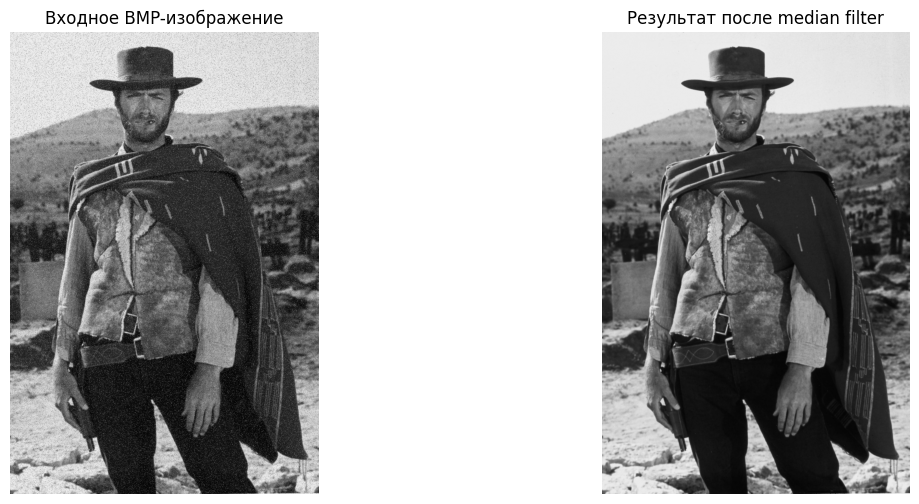

In [33]:
# просмотр результата

from PIL import Image
import matplotlib.pyplot as plt

img_in = Image.open("input.bmp")
img_out = Image.open("output.bmp")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_in, cmap="gray")
plt.title("Входное BMP-изображение")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_out, cmap="gray")
plt.title("Результат после median filter")
plt.axis("off")

plt.show()

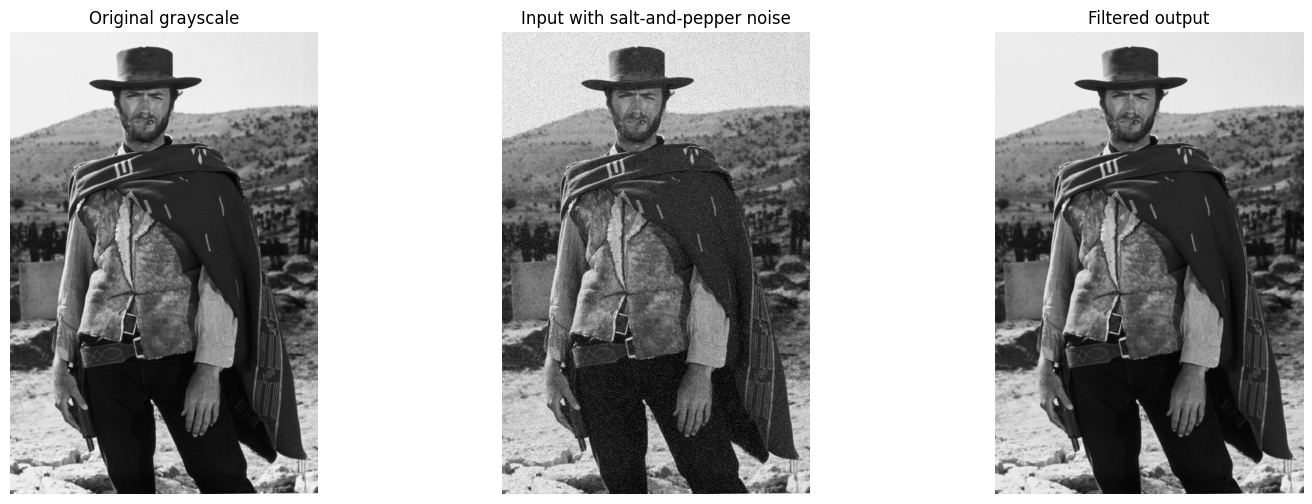

In [41]:
from PIL import Image
import matplotlib.pyplot as plt

img_orig = Image.open("original_gray.bmp")
img_in = Image.open("input.bmp")
img_out = Image.open("output.bmp")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_orig, cmap="gray")
plt.title("Original grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_in, cmap="gray")
plt.title("Input with salt-and-pepper noise")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_out, cmap="gray")
plt.title("Filtered output")
plt.axis("off")

plt.show()

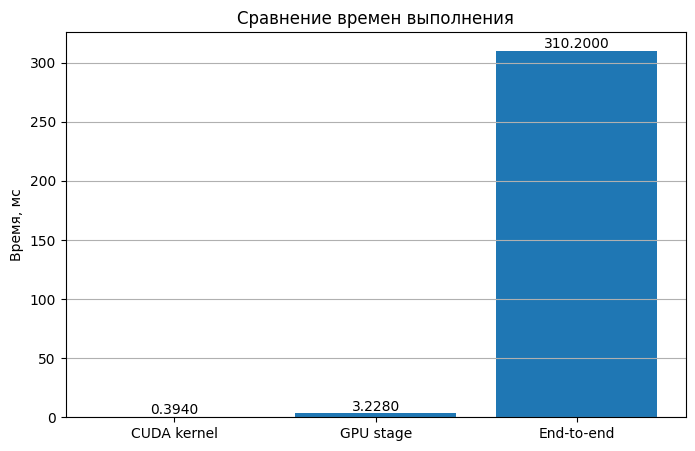

In [34]:
import matplotlib.pyplot as plt

plot_df = timing_df_round.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Метрика времени"], plot_df["Значение, мс"])
plt.title("Сравнение времен выполнения")
plt.ylabel("Время, мс")
plt.grid(True, axis="y")

for i, v in enumerate(plot_df["Значение, мс"]):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.show()

In [35]:
import numpy as np
import pandas as pd
from PIL import Image
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

orig = np.array(Image.open("original_gray.bmp").convert("L"), dtype=np.uint8)
noisy = np.array(Image.open("input.bmp").convert("L"), dtype=np.uint8)
filt = np.array(Image.open("output.bmp").convert("L"), dtype=np.uint8)

def impulse_fraction(img):
    total = img.size
    extreme = np.sum((img == 0) | (img == 255))
    return extreme / total

metrics_df = pd.DataFrame([
    {
        "Сравнение": "original vs noisy",
        "MSE": mean_squared_error(orig, noisy),
        "PSNR": peak_signal_noise_ratio(orig, noisy, data_range=255),
        "SSIM": structural_similarity(orig, noisy, data_range=255),
        "Доля 0/255": impulse_fraction(noisy)
    },
    {
        "Сравнение": "original vs filtered",
        "MSE": mean_squared_error(orig, filt),
        "PSNR": peak_signal_noise_ratio(orig, filt, data_range=255),
        "SSIM": structural_similarity(orig, filt, data_range=255),
        "Доля 0/255": impulse_fraction(filt)
    }
])

metrics_df_round = metrics_df.copy()
for col in ["MSE", "PSNR", "SSIM", "Доля 0/255"]:
    metrics_df_round[col] = metrics_df_round[col].round(4)

print("Обычная таблица:")
print(metrics_df.to_string(index=False))

print("\nКомпактная таблица:")
print(metrics_df_round.to_string(index=False))

print("\nТаблица с округлением до 4 знаков:")
print(metrics_df_round.to_string(index=False))

Обычная таблица:
           Сравнение         MSE      PSNR     SSIM  Доля 0/255
   original vs noisy 1808.347648 15.557984 0.165347     0.07995
original vs filtered    3.657792 42.498614 0.986464     0.00003

Компактная таблица:
           Сравнение       MSE    PSNR   SSIM  Доля 0/255
   original vs noisy 1808.3476 15.5580 0.1653      0.0799
original vs filtered    3.6578 42.4986 0.9865      0.0000

Таблица с округлением до 4 знаков:
           Сравнение       MSE    PSNR   SSIM  Доля 0/255
   original vs noisy 1808.3476 15.5580 0.1653      0.0799
original vs filtered    3.6578 42.4986 0.9865      0.0000


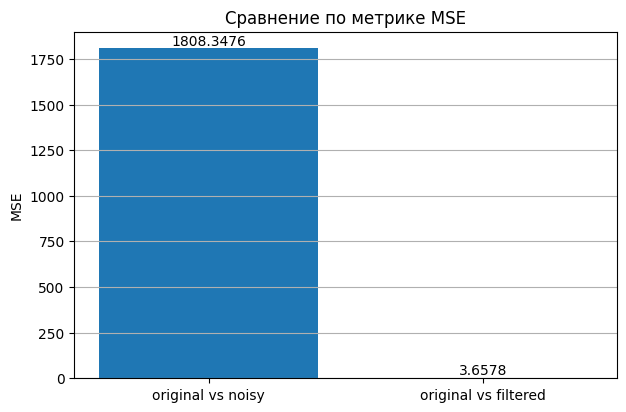

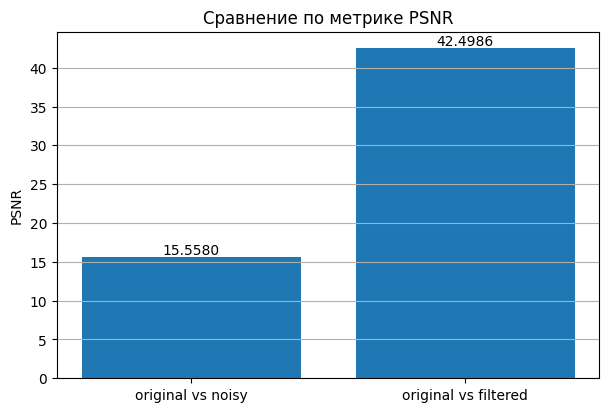

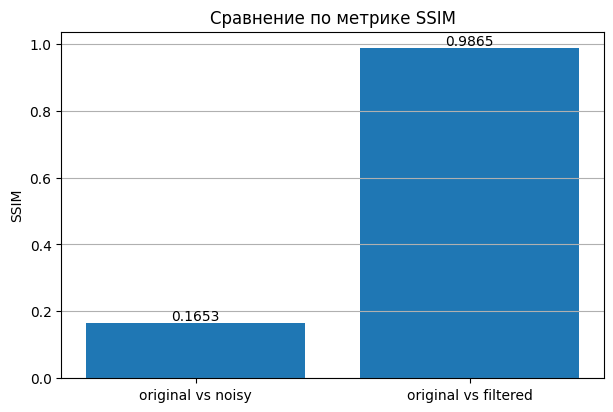

In [36]:
import matplotlib.pyplot as plt

pairs = metrics_df_round["Сравнение"]

for metric in ["MSE", "PSNR", "SSIM"]:
    plt.figure(figsize=(7, 4.5))
    vals = metrics_df_round[metric]
    plt.bar(pairs, vals)
    plt.title(f"Сравнение по метрике {metric}")
    plt.ylabel(metric)
    plt.grid(True, axis="y")
    for i, v in enumerate(vals):
        plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")
    plt.show()

Изображение  Доля 0/255
   Original      0.0000
      Noisy      0.0799
   Filtered      0.0000


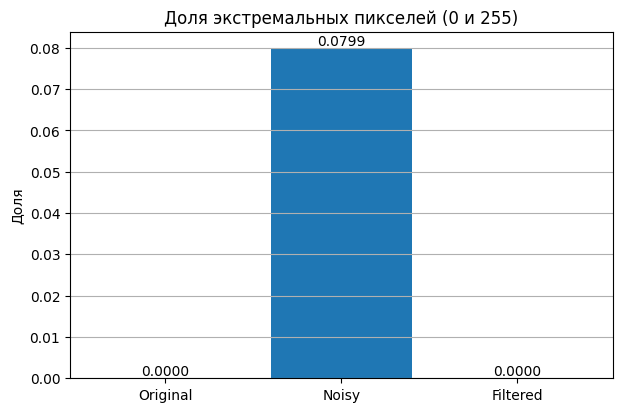

In [37]:
impulse_df = pd.DataFrame([
    {"Изображение": "Original", "Доля 0/255": impulse_fraction(orig)},
    {"Изображение": "Noisy", "Доля 0/255": impulse_fraction(noisy)},
    {"Изображение": "Filtered", "Доля 0/255": impulse_fraction(filt)},
])

impulse_df_round = impulse_df.copy()
impulse_df_round["Доля 0/255"] = impulse_df_round["Доля 0/255"].round(4)

print(impulse_df_round.to_string(index=False))

plt.figure(figsize=(7, 4.5))
plt.bar(impulse_df_round["Изображение"], impulse_df_round["Доля 0/255"])
plt.title("Доля экстремальных пикселей (0 и 255)")
plt.ylabel("Доля")
plt.grid(True, axis="y")

for i, v in enumerate(impulse_df_round["Доля 0/255"]):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.show()

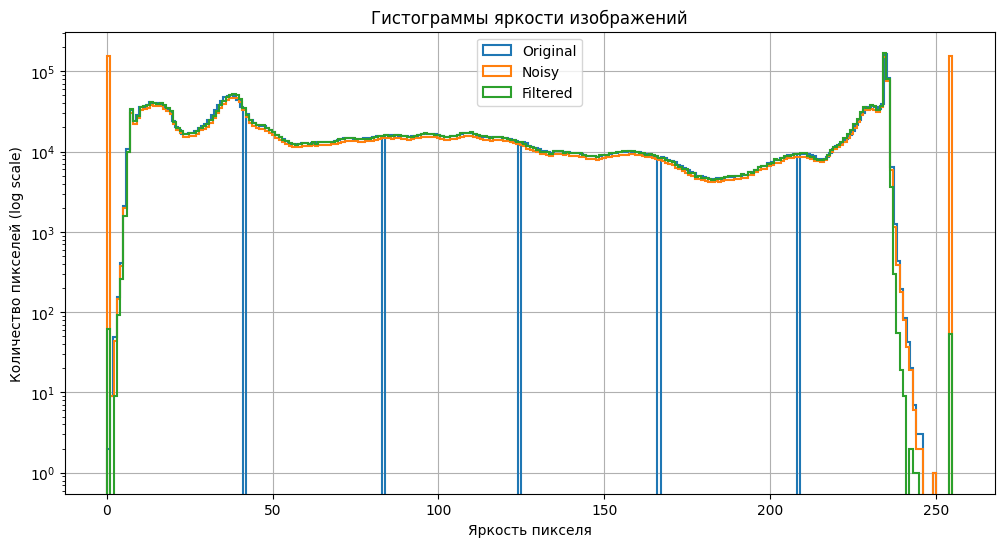

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(orig.ravel(), bins=256, histtype="step", linewidth=1.5, label="Original")
plt.hist(noisy.ravel(), bins=256, histtype="step", linewidth=1.5, label="Noisy")
plt.hist(filt.ravel(), bins=256, histtype="step", linewidth=1.5, label="Filtered")
plt.yscale("log")
plt.title("Гистограммы яркости изображений")
plt.xlabel("Яркость пикселя")
plt.ylabel("Количество пикселей (log scale)")
plt.legend()
plt.grid(True)
plt.show()

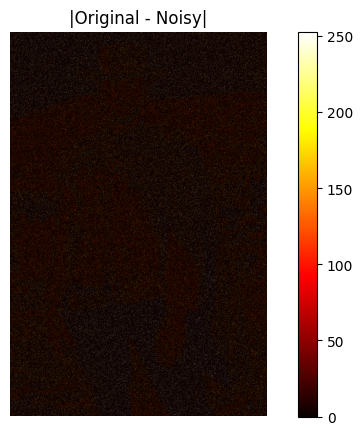

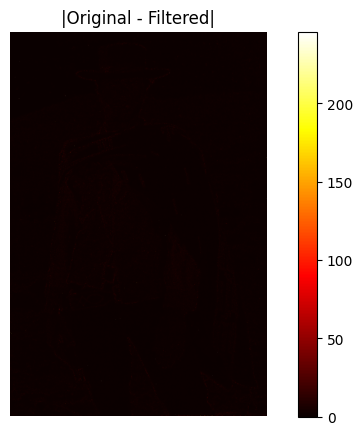

In [39]:
diff_noisy = np.abs(orig.astype(np.int16) - noisy.astype(np.int16)).astype(np.uint8)
diff_filt = np.abs(orig.astype(np.int16) - filt.astype(np.int16)).astype(np.uint8)

plt.figure(figsize=(8, 5))
plt.imshow(diff_noisy, cmap="hot")
plt.title("|Original - Noisy|")
plt.axis("off")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 5))
plt.imshow(diff_filt, cmap="hot")
plt.title("|Original - Filtered|")
plt.axis("off")
plt.colorbar()
plt.show()

In [40]:
# скачать результат

from google.colab import files
files.download("output.bmp")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>